# Unit 8 Artefact 2: Reproducing Aijaz and Nazir's (2024) Social Engineering Model

Ian Stevens, Security and Risk Management, Unit 8.

Aijaz and Nazir (2024) model a social engineering threat (SET) in two parts. An **attack tree** gives the attack occurrence probability (AOP) from the frequency of each communication channel (modality) and persuasion principle, and a **Markov chain** with four attacker states gives the attack success probability (ASP) from their effectiveness. Their Table 3 reports both figures for ten case scenarios.

Before using the method on Pampered Pets (Artefact 3), this notebook asks three questions:

1. Can Table 3 be reproduced from the inputs in Tables 1 and 2?
2. What do AOP and ASP actually measure?
3. How much of the ranking in Table 3 is signal and how much is Monte Carlo noise?

All inputs are the figures printed in the paper. Nothing here is new data.

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
pd.set_option("display.width", 140)

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "lines.linewidth": 2,
})
BLUE, ORANGE, AQUA, INK = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"

## 1. The published inputs

Tables 1 and 2 of the paper give an occurrence probability and an effectiveness probability for each modality and persuasion principle. The paper's table titles call them *assumed* frequency and effectiveness, taken from published studies (Bullée et al., 2018; Mouton, Leenen and Venter, 2016).

In [2]:
modality = pd.DataFrame({
    "occurrence": [0.5, 0.4, 0.1],
    "effectiveness": [0.2, 0.3, 0.4],
}, index=["email", "voice call", "face to face"])

principle = pd.DataFrame({
    "occurrence": [0.63, 0.11, 0.11, 0.01, 0.006, 0.13],
    "effectiveness": [0.63, 0.29, 0.41, 0.45, np.nan, np.nan],
}, index=["authority", "commitment", "reciprocity", "conformity", "scarcity", "liking"])

print("Sum of modality occurrence probabilities:  ", modality["occurrence"].sum())
print("Sum of principle occurrence probabilities: ", round(principle["occurrence"].sum(), 3))
pd.concat({"Modality (Table 1)": modality, "Persuasion principle (Table 2)": principle})

Sum of modality occurrence probabilities:   1.0
Sum of principle occurrence probabilities:  0.996

occurrence  effectiveness
Modality (Table 1)             email              0.500           0.20
                               voice call         0.400           0.30
                               face to face       0.100           0.40
Persuasion principle (Table 2) authority          0.630           0.63
                               commitment         0.110           0.29
                               reciprocity        0.110           0.41
                               conformity         0.010           0.45
                               scarcity           0.006            NaN
                               liking             0.130            NaN

Both occurrence columns sum to 1. They are **shares**: of the attacks in the source data, half used email and 63% used authority. They are not the probability that an organisation suffers an attack in a given period, and nothing in the tables has a time base. Authority's effectiveness (0.63) is also identical to its occurrence share, which looks like a copied value.

## 2. Attack tree: reproducing the AOP column

The paper's Algorithm 1 evaluates a static attack tree from the bottom up: an OR node takes the **maximum** of its children and an AND node takes the **product**. Each case scenario combines one or two modalities with one or two persuasion principles.

In [3]:
def compute_aop(node):
    # Algorithm 1 of Aijaz and Nazir (2024): OR = max, AND = product
    kind = node[0]
    if kind == "leaf":
        return node[1]
    values = [compute_aop(child) for child in node[1]]
    return max(values) if kind == "OR" else float(np.prod(values))

leaf_m = lambda m: ("leaf", modality.loc[m, "occurrence"])
leaf_p = lambda p: ("leaf", principle.loc[p, "occurrence"])

def modality_node(mods):
    return leaf_m(mods[0]) if len(mods) == 1 else ("OR", [leaf_m(m) for m in mods])

cases = pd.DataFrame([
    (1, ["email"], ["authority"], 31.5, 12.0),
    (2, ["email"], ["reciprocity"], 5.5, 7.7),
    (3, ["email"], ["commitment"], 5.5, 8.4),
    (4, ["voice call"], ["authority"], 25.2, 11.4),
    (5, ["voice call"], ["reciprocity"], 4.4, 10.0),
    (6, ["voice call"], ["commitment"], 4.4, 10.9),
    (7, ["face to face"], ["authority"], 6.3, 16.0),
    (8, ["voice call", "email"], ["authority", "reciprocity"], 1.7, 15.0),
    (9, ["voice call"], ["authority", "commitment"], 1.1, 18.0),
    (10, ["email"], ["commitment", "reciprocity"], 0.3, 15.0),
], columns=["case", "modality", "principles", "AOP published %", "ASP published %"]).set_index("case")
cases

,modality,principles,AOP published %,ASP published %
case,,,,
1,[email],[authority],31.5,12.0
2,[email],[reciprocity],5.5,7.7
3,[email],[commitment],5.5,8.4
4,[voice call],[authority],25.2,11.4
5,[voice call],[reciprocity],4.4,10.0
6,[voice call],[commitment],4.4,10.9
7,[face to face],[authority],6.3,16.0
8,"[voice call, email]","[authority, reciprocity]",1.7,15.0
9,[voice call],"[authority, commitment]",1.1,18.0


For the single-principle cases the tree is simply AND(modality, principle). For the three multi-principle cases there are two ways to draw it:

* **Shared leaf:** the modality appears once, AND(modality, principle 1, principle 2).
* **Repeated leaf:** each principle gets its own branch with its own copy of the modality, AND(AND(modality, principle 1), AND(modality, principle 2)). This is the shape of the paper's Figure 2.

In [4]:
def tree_shared(mods, prins):
    return ("AND", [modality_node(mods)] + [leaf_p(p) for p in prins])

def tree_repeated(mods, prins):
    return ("AND", [("AND", [modality_node(mods), leaf_p(p)]) for p in prins])

cases["AOP shared leaf %"] = [100 * compute_aop(tree_shared(m, p)) for m, p in zip(cases.modality, cases.principles)]
cases["AOP repeated leaf %"] = [100 * compute_aop(tree_repeated(m, p)) for m, p in zip(cases.modality, cases.principles)]
cases[["modality", "principles", "AOP published %", "AOP shared leaf %", "AOP repeated leaf %"]].round(2)

,modality,principles,AOP published %,AOP shared leaf %,AOP repeated leaf %
case,,,,,
1,[email],[authority],31.5,31.50,31.50
2,[email],[reciprocity],5.5,5.50,5.50
3,[email],[commitment],5.5,5.50,5.50
4,[voice call],[authority],25.2,25.20,25.20
5,[voice call],[reciprocity],4.4,4.40,4.40
6,[voice call],[commitment],4.4,4.40,4.40
7,[face to face],[authority],6.3,6.30,6.30
8,"[voice call, email]","[authority, reciprocity]",1.7,3.46,1.73
9,[voice call],"[authority, commitment]",1.1,2.77,1.11


Every published AOP is reproduced, but only with the **repeated leaf**. In cases 8 to 10 the modality probability is multiplied in twice, as if the attacker had to choose email independently for each sentence of the same message. That is the 'repeated labelling' problem the authors say they intend to address in future work, and it halves the AOP of every multi-principle scenario.

Two further points:

* The text of case 9 gives the modality as 'voice call, email', but the published 1.1% only comes out if voice call is used alone, as in Table 3.
* The paper's first finding, that AOP falls when more than one principle is used, follows from the arithmetic: multiplying by another number below one always makes the product smaller. It is not evidence about attackers. Bullée et al. (2018) did find that single-principle attack steps are more common than multi-principle ones, but in counts, not by multiplying shares.

In [5]:
# OR as 'max' (the attacker picks the best option) versus the probability that at least one branch occurs
or_max = compute_aop(("OR", [leaf_m("voice call"), leaf_m("email")]))
or_any = 1 - (1 - 0.4) * (1 - 0.5)
print(f"Case 8 modality node: OR = max gives {or_max:.2f}; OR = 'at least one' gives {or_any:.2f}")
print("Because the occurrence values are shares that sum to 1, neither reading is a probability that the attack happens.")

Case 8 modality node: OR = max gives 0.50; OR = 'at least one' gives 0.70
Because the occurrence values are shares that sum to 1, neither reading is a probability that the attack happens.

## 3. Markov chain: what the ASP measures

The chain in Figure 3 has four states. From **Disconnect** the attacker connects with probability α or stays put; from **Connect** they move to **Persuade** with probability β or fall back to Disconnect; from **Persuade** they reach **Success** with probability γ or fall back to Disconnect. Success is absorbing, so the authors add a transition from Success back to every state with probability 1/4 to make the chain irreducible, and estimate its stationary distribution by Monte Carlo. ASP is the stationary probability of Success.

The paper says the transition probabilities 'depend on' the effectiveness values, but not which value goes where. I start with the most natural reading: α is the modality's effectiveness and β and γ are the principle's.

In [6]:
S = ["Disconnect", "Connect", "Persuade", "Success"]

def transition(a, b, g, restart=(0.25, 0.25, 0.25, 0.25)):
    return np.array([[1 - a, a, 0, 0],
                     [1 - b, 0, b, 0],
                     [1 - g, 0, 0, g],
                     list(restart)])

def stationary(P):
    # exact solution of pi P = pi with sum(pi) = 1: no simulation needed
    A = np.vstack([P.T - np.eye(len(P)), np.ones(len(P))])
    rhs = np.r_[np.zeros(len(P)), 1.0]
    return np.linalg.lstsq(A, rhs, rcond=None)[0]

a, b, g = modality.loc["email", "effectiveness"], principle.loc["authority", "effectiveness"], principle.loc["authority", "effectiveness"]
P1 = transition(a, b, g)
pd.DataFrame(P1, index=S, columns=S).round(3)

,Disconnect,Connect,Persuade,Success
Disconnect,0.80,0.20,0.00,0.00
Connect,0.37,0.00,0.63,0.00
Persuade,0.37,0.00,0.00,0.63
Success,0.25,0.25,0.25,0.25


In [7]:
pi = stationary(P1)
print("Exact stationary distribution, case 1 (email, authority):")
print(pd.Series(pi, index=S).round(4).to_string())
print(f"\nASP under this reading: {100*pi[3]:.1f}%  (published: 12.0%)")

Exact stationary distribution, case 1 (email, authority):
Disconnect    0.6279
Connect       0.1508
Persuade      0.1203
Success       0.1010

ASP under this reading: 10.1%  (published: 12.0%)

### 3.1 Can the ASP column be reproduced at all?

The inputs could be mapped to α, β and γ in many ways. I tried eight candidate values for each of the three transitions (the modality effectiveness m, the principle effectiveness p, their product, their average, their complements, 'at least one' and 1), which gives 512 mappings, and compared each with the seven single-principle cases.

In [8]:
single = cases.loc[1:7]
eff_m = single.modality.map(lambda m: modality.loc[m[0], "effectiveness"]).values
eff_p = single.principles.map(lambda p: principle.loc[p[0], "effectiveness"]).values
target = single["ASP published %"].values

options = {"m": lambda m, p: m, "p": lambda m, p: p, "m*p": lambda m, p: m * p, "(m+p)/2": lambda m, p: (m + p) / 2,
           "1-m": lambda m, p: 1 - m, "1-p": lambda m, p: 1 - p, "m+p-mp": lambda m, p: m + p - m * p, "1": lambda m, p: 1.0}

rows = []
for A, B, G in itertools.product(options, repeat=3):
    est = np.array([100 * stationary(transition(options[A](m, p), options[B](m, p), options[G](m, p)))[3]
                    for m, p in zip(eff_m, eff_p)])
    rows.append({"alpha": A, "beta": B, "gamma": G, "RMSE (points)": np.sqrt(((est - target) ** 2).mean()),
                 "max error (points)": np.abs(est - target).max(), "estimates": np.round(est, 1)})
search = pd.DataFrame(rows).sort_values("RMSE (points)").reset_index(drop=True)
print("Mappings tried:", len(search))
print("Published ASP, cases 1-7:", target)
search.head(5).round(2)

Mappings tried: 512
Published ASP, cases 1-7: [12.   7.7  8.4 11.4 10.  10.9 16. ]

,alpha,beta,gamma,RMSE (points),max error (points),estimates
0,m+p-mp,m,1-m,1.50,2.91,"[10.1, 8.8, 7.8, 12.2, 11.1, 10.3, 13.1]"
1,(m+p)/2,1-p,m+p-mp,1.51,2.21,"[11.1, 9.9, 8.1, 12.6, 12.2, 10.7, 14.0]"
2,1-p,(m+p)/2,m+p-mp,1.65,2.75,"[11.5, 8.1, 5.9, 13.5, 10.4, 8.1, 15.6]"
3,1-m,1,m,1.69,3.88,"[8.1, 8.1, 8.1, 11.6, 11.6, 11.6, 14.7]"
4,m+p-mp,1,m,1.86,4.23,"[7.8, 6.9, 6.3, 11.8, 10.9, 10.3, 16.0]"


None of the 512 mappings reproduces the column. The closest is still 1.5 points out on average and over 3 points out in at least one case, and uses combinations that make little sense (for example the complement of the modality's effectiveness as the chance of success). The published order also contradicts the inputs. Reciprocity (0.41) is more effective than commitment (0.29), yet commitment scores higher with both email and voice, and email with authority (12.0%) beats voice call with authority (11.4%) although voice is the more effective channel. No model that increases with effectiveness can produce both orderings.

### 3.2 Monte Carlo noise

The paper estimated the stationary distribution with a Monte Carlo random walk but does not say how long the walk was. The exact answer is available from linear algebra, so the noise can be measured directly.

In [9]:
def random_walk(P, n_steps):
    cum = P.cumsum(axis=1)
    state, hits = 0, 0
    for u in rng.random(n_steps):
        state = int(np.searchsorted(cum[state], u))
        hits += state == 3
    return hits / n_steps

exact = 100 * stationary(P1)[3]
noise = []
for n in [100, 1_000, 10_000]:
    est = 100 * np.array([random_walk(P1, n) for _ in range(400)])
    lo, hi = np.percentile(est, [2.5, 97.5])
    noise.append({"walk length (steps)": n, "mean estimate %": est.mean(), "95% of estimates from %": lo, "to %": hi,
                  "half-width (points)": (hi - lo) / 2})
noise = pd.DataFrame(noise).set_index("walk length (steps)")
print(f"Exact value: {exact:.2f}%")
noise.round(2)

Exact value: 10.10%

,mean estimate %,95% of estimates from %,to %,half-width (points)
walk length (steps),,,,
100,9.56,2.00,18.00,8.00
1000,9.97,7.50,12.50,2.50
10000,10.10,9.35,10.91,0.78


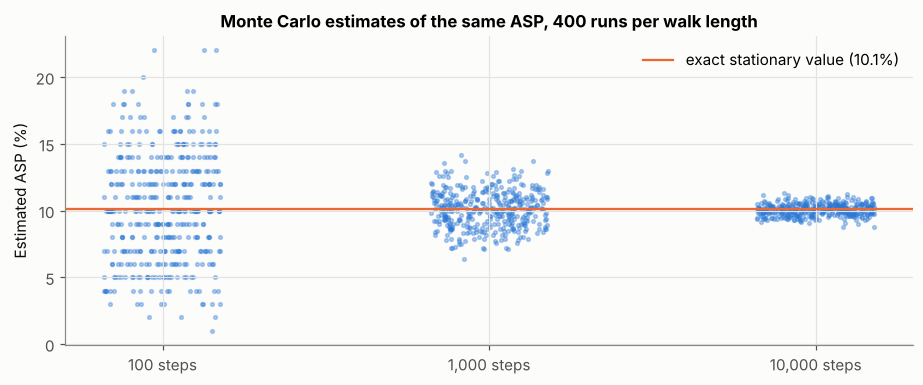

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
for i, n in enumerate([100, 1_000, 10_000]):
    est = 100 * np.array([random_walk(P1, n) for _ in range(400)])
    ax.scatter(np.full(est.size, i) + rng.uniform(-0.18, 0.18, est.size), est, s=6, alpha=0.35, color=BLUE)
ax.axhline(exact, color=ORANGE, lw=1.5, label=f"exact stationary value ({exact:.1f}%)")
ax.set_xticks([0, 1, 2], ["100 steps", "1,000 steps", "10,000 steps"])
ax.set_ylabel("Estimated ASP (%)")
ax.set_title("Monte Carlo estimates of the same ASP, 400 runs per walk length")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig("figures/u8_asp_noise.png", dpi=150)

With a walk of 1,000 steps the estimate of one scenario can land anywhere from about 7.5% to 12.5%. Most of the gaps between scenarios in Table 3 are smaller than that, so the paper's ranking of SETs by ASP may be partly noise. This is the lesson of Unit 7 again: when an exact answer exists, use it, and keep the simulation as a check.

### 3.3 What the stationary probability means

Without the added restart, Success is absorbing and every failure sends the attacker back to Disconnect to try again. Any chain with α, β and γ above zero therefore reaches Success with probability 1. The stationary value after the restart measures how **often** the walk sits in Success, which depends on how many steps an attack takes and on the restart rule the authors invented.

In [11]:
Q = P1[:3, :3]                                   # transient part of the original (absorbing) chain
steps_to_success = np.linalg.inv(np.eye(3) - Q).sum(axis=1)

rules = {"restart to every state with 1/4 (paper)": (0.25, 0.25, 0.25, 0.25),
         "restart to Disconnect (a fresh attack)": (1, 0, 0, 0),
         "restart to Connect (attacker keeps the contact)": (0, 1, 0, 0)}
restart = pd.DataFrame({"ASP %": {k: 100 * stationary(transition(a, b, g, r))[3] for k, r in rules.items()}})
print("Probability of eventual success in the original chain: 1.0 (Success is the only absorbing state)")
print(f"Expected steps to success from Disconnect: {steps_to_success[0]:.1f}")
print(f"Check: 1 / (1 + expected steps) = {100/(1+steps_to_success[0]):.2f}%, the 'restart to Disconnect' value below\n")
restart.round(2)

Probability of eventual success in the original chain: 1.0 (Success is the only absorbing state)
Expected steps to success from Disconnect: 16.7
Check: 1 / (1 + expected steps) = 5.65%, the 'restart to Disconnect' value below

,ASP %
restart to every state with 1/4 (paper),10.10
restart to Disconnect (a fresh attack),5.65
restart to Connect (attacker keeps the contact),7.87


Changing nothing about the attack and only the restart rule moves the 'success probability' from 10.1% to 5.6% or 13.4%. With a restart to Disconnect the ASP is exactly 1 / (1 + expected number of steps to success), so it is a measure of **speed**, not of the chance that an attempt works. A probability that a single attempt succeeds needs a failure state the attacker cannot leave, such as the target reporting the message. Artefact 3 builds the chain that way.

## 4. Summary

| Question | Finding |
|---|---|
| Does the AOP column reproduce? | Yes, all ten values, but only if the modality is counted once per principle in multi-principle scenarios (repeated leaf). Case 9 uses voice call only, against the text. |
| What is AOP? | The share of attacks with a given combination of modality and principles, assuming independence. It has no time base and is not an occurrence likelihood for an organisation. |
| Does the ASP column reproduce? | No. None of 512 mappings of the effectiveness values to α, β and γ matches it, and its ordering contradicts the inputs. |
| What is ASP? | The long-run share of time spent in Success in a chain where success is certain in the end. It changes with an arbitrary restart rule and measures speed, not chance. |
| Noise | A 1,000-step walk gives about ±2.5 points on a single ASP, larger than most differences between scenarios. |

### References

Aijaz, M. and Nazir, M. (2024) 'Modelling and analysis of social engineering threats using the attack tree and the Markov model', *International Journal of Information Technology*, 16(2), pp. 1231–1238. https://doi.org/10.1007/s41870-023-01540-z

Bullée, J.-W.H., Montoya, L., Pieters, W., Junger, M. and Hartel, P. (2018) 'On the anatomy of social engineering attacks: a literature-based dissection of successful attacks', *Journal of Investigative Psychology and Offender Profiling*, 15(1), pp. 20–45. https://doi.org/10.1002/jip.1482

Mouton, F., Leenen, L. and Venter, H.S. (2016) 'Social engineering attack examples, templates and scenarios', *Computers & Security*, 59, pp. 186–209. https://doi.org/10.1016/j.cose.2016.03.004